In [329]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

sns.set_context("paper")

PROJECT_ROOT = Path.cwd().parents[1]

RESULTS_DIR = PROJECT_ROOT / "results_for_paper_backup" / "sepsis" / "generated_trajectories"
DATA_DIR = PROJECT_ROOT / "data" / "processed"

metadata = pd.read_csv(DATA_DIR / "mouse_sepsis_proteomics_metadata_batch_corrected.csv")
quant = pd.read_csv(DATA_DIR / "mouse_sepsis_proteomics_data_batch_corrected.csv")
annotations = pd.read_csv(DATA_DIR / "sepsis_uniprot_annotations.csv").fillna("")

rename_map = dict(zip(annotations["source_id"], annotations["display_name"]))
quant = quant.rename(columns=rename_map)

df = (
    quant.merge(metadata, on="Run", how="left")
    .rename(columns={"Model": "model", "Tissue": "tissue", "nhpi": "time", "hpi": "hpi"})
    .melt(
        id_vars=["Run", "model", "tissue", "time", "hpi"],
        var_name="protein",
        value_name="abundance",
    )
    .sort_values(["model", "tissue", "time", "Run", "protein"])
    .reset_index(drop=True)
)
df.head()

,Run,model,tissue,time,hpi,protein,abundance
0,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Acat2,20.160688
1,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Aco1,21.689276
2,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Aco2,22.988321
3,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Actr3,21.923648
4,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Afm,20.665359


In [307]:
df["time_discrete"] = np.where(df["time"] < 0.5, "low", "high")
de_results = []
for protein in df["protein"].unique():
    df_protein = df[df["protein"] == protein]
    abundances_low = df_protein.loc[
        df_protein["time_discrete"] == "low", "abundance"
    ].values
    abundances_high = df_protein.loc[
        df_protein["time_discrete"] == "high", "abundance"
    ].values
    
    statistic, pvalue = ttest_ind(
        abundances_low,
        abundances_high,
        equal_var=False,  # Welch t-test
        nan_policy="omit"
    )

    mean_low = np.mean(abundances_low)
    mean_high = np.mean(abundances_high)

    # avoid division by zero
    pseudocount = 1e-9
    log2_fc = np.log2((mean_high + pseudocount) / (mean_low + pseudocount))

    de_results.append({
        "protein": protein,
        "mean_low": mean_low,
        "mean_high": mean_high,
        "log2_fc": log2_fc,
        "statistic": statistic,
        "pvalue": pvalue,
    })

de_df = pd.DataFrame(de_results)
_, de_df["adj_pvalue"] = fdrcorrection(de_df["pvalue"])
de_df["neg_log10_adj_pvalue"] = -np.log10(de_df["adj_pvalue"])
de_df.sort_values("log2_fc", ascending=False).head(10)


,protein,mean_low,mean_high,log2_fc,statistic,pvalue,adj_pvalue,neg_log10_adj_pvalue
219,Saa2,16.899773,23.755034,0.491229,-33.450073,6.001713e-140,2.246355e-138,137.648522
218,Saa1,17.426545,24.138769,0.470066,-37.645620,6.704100e-163,4.391185e-161,160.357418
148,Lcn2,19.439678,23.908976,0.298548,-22.685424,3.953440e-84,6.092949e-83,82.215172
15,Apcs,18.333352,22.511647,0.296201,-34.481554,3.369629e-150,1.765686e-148,147.753087
111,Hp,20.796301,25.453504,0.291537,-32.443387,2.374914e-141,1.037046e-139,138.984202
229,Serpina3n,20.045382,23.995376,0.259487,-53.250306,1.274644e-248,3.339569e-246,245.476310
161,Ngp,19.541290,21.924447,0.166015,-15.506208,2.237172e-46,2.170885e-45,44.663363
217,S100a9,20.202545,22.618950,0.162995,-18.113721,2.931271e-59,3.071972e-58,57.512583
152,Lrg1,21.618717,24.116579,0.157744,-37.226393,2.634310e-168,2.300631e-166,165.638153
138,Itih4,21.695859,24.076940,0.150232,-41.200588,2.015362e-169,2.640125e-167,166.578376


In [308]:
runs = []
for n in range(5):
    run_n = pd.read_csv(RESULTS_DIR / f"replicate_0{n + 1}_seed_{n + 42}.csv")
    runs.append(run_n)
runs = pd.concat(runs, ignore_index=True)
display(runs["replicate"].unique())
runs = runs[runs["datasplit"] == "val"].copy()
runs.head()


array([1, 2, 3, 4, 5])

,model,tissue,start_sample,datasplit,replicate,seed,path_id,trajectory_replicate,step,t,protein,abundance,velocity
2311626,IP-Eco,Heart,TiM_P1908_123,val,1,42,0,0,0,0.00,Fga,23.608811,0.615006
2311627,IP-Eco,Heart,TiM_P1908_123,val,1,42,0,0,1,0.02,Fga,23.621416,0.645863
2311628,IP-Eco,Heart,TiM_P1908_123,val,1,42,0,0,2,0.04,Fga,23.634661,0.678735
2311629,IP-Eco,Heart,TiM_P1908_123,val,1,42,0,0,3,0.06,Fga,23.648580,0.713273
2311630,IP-Eco,Heart,TiM_P1908_123,val,1,42,0,0,4,0.08,Fga,23.663205,0.749090


In [309]:
runs_grouped = runs[["protein", "velocity"]].groupby("protein", as_index=False).mean()
de_df = de_df.merge(runs_grouped, on="protein")

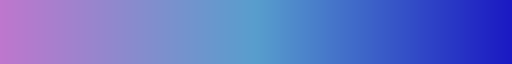

In [310]:
pink_cmap = sns.blend_palette(
    ["#BE77CE", "#589ECD", "#1B19C3"],
    as_cmap=True
)
pink_cmap

np.float64(0.9674979507314815)

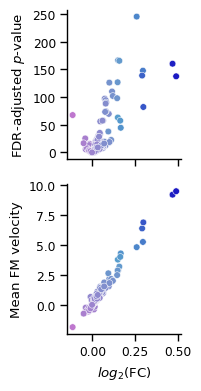

In [311]:
fig, axs = plt.subplots(2,1, figsize=(2,4), sharex=True)
sns.scatterplot(de_df, x="log2_fc", y="neg_log10_adj_pvalue", hue="velocity", ax=axs[0], palette=pink_cmap)
statistic, pvalue = spearmanr(de_df["log2_fc"], de_df["velocity"])
display(statistic)
sns.scatterplot(de_df, x="log2_fc", y="velocity", ax=axs[1], hue="velocity", palette=pink_cmap)
for ax in axs.ravel():
    ax.legend().remove()

plt.xlabel(r"${log_2}$(FC)")
axs[0].set_ylabel(r"FDR-adjusted $p$-value")
axs[1].set_ylabel("Mean FM velocity")
sns.despine()
plt.tight_layout()
plt.savefig("/Users/erikhartman/dev/flow-matching/panels/sepsis/fc_vel_scatter.svg", bbox_inches="tight")

In [312]:
# Finite difference derivative for proteins (log fc between time points)
# Correlate with velocity in time interval

observed_means = (
    df.groupby(["model", "tissue", "protein", "time"], as_index=False)["abundance"]
    .mean()
    .sort_values(["model", "tissue", "protein", "time"])
)

observed_means["time_next"] = observed_means.groupby(
    ["model", "tissue", "protein"]
)["time"].shift(-1)
observed_means["abundance_next"] = observed_means.groupby(
    ["model", "tissue", "protein"]
)["abundance"].shift(-1)

protein_derivative = observed_means.dropna(
    subset=["time_next", "abundance_next"]
).copy()
protein_derivative["dt"] = protein_derivative["time_next"] - protein_derivative["time"]
protein_derivative = protein_derivative[protein_derivative["dt"] > 0].copy()
protein_derivative["log_fc"] = (
    protein_derivative["abundance_next"] - protein_derivative["abundance"]
)
protein_derivative["finite_difference"] = (
    protein_derivative["log_fc"] / protein_derivative["dt"]
)
protein_derivative


,model,tissue,protein,time,abundance,time_next,abundance_next,dt,log_fc,finite_difference
0,IN-Kpn,Leukocytes,Acat2,0.000000,20.526733,0.150000,20.467885,0.150000,-0.058848,-0.392318
1,IN-Kpn,Leukocytes,Acat2,0.150000,20.467885,0.400000,21.242397,0.250000,0.774512,3.098047
2,IN-Kpn,Leukocytes,Acat2,0.400000,21.242397,1.000000,21.519340,0.600000,0.276944,0.461573
4,IN-Kpn,Leukocytes,Aco1,0.000000,21.627592,0.150000,21.537712,0.150000,-0.089879,-0.599194
5,IN-Kpn,Leukocytes,Aco1,0.150000,21.537712,0.400000,21.128871,0.250000,-0.408841,-1.635366
...,...,...,...,...,...,...,...,...,...,...
23573,SC-Spy,Plasma,Ywhag,0.666667,23.674752,1.000000,23.935041,0.333333,0.260290,0.780869
23575,SC-Spy,Plasma,Ywhaz,0.000000,23.104169,0.166667,21.951658,0.166667,-1.152511,-6.915067
23576,SC-Spy,Plasma,Ywhaz,0.166667,21.951658,0.333333,23.144726,0.166667,1.193069,7.158412
23577,SC-Spy,Plasma,Ywhaz,0.333333,23.144726,0.666667,25.677236,0.333333,2.532510,7.597529


In [313]:
velocity_by_time = (
    runs.groupby(["model", "tissue", "protein", "t"], as_index=False)["velocity"]
    .mean()
)

interval_velocity = protein_derivative[["model", "tissue", "protein", "time", "time_next", "finite_difference"]].merge(
    velocity_by_time,
    on=["model", "tissue", "protein"],
    how="left",
)

interval_velocity["keep"] = interval_velocity.apply(lambda row: row["time"] <= row["t"] < row["time_next"], axis=1 )
interval_velocity = interval_velocity[interval_velocity["keep"] == True]
interval_velocity["mean_time"] = interval_velocity["time"] + (interval_velocity["time_next"] - interval_velocity["time"])/2
interval_velocity_grouped = interval_velocity[["protein", "velocity", "finite_difference", "tissue", "model", "time", "time_next", "mean_time"]].groupby(
    ["protein", "tissue", "model", "time", "time_next"]).mean()

In [314]:
interval_velocity.sort_values("finite_difference", ascending=False).head(10)

,model,tissue,protein,time,time_next,finite_difference,t,velocity,keep,mean_time
405112,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.38,5.718514,True,0.388889
405110,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.34,6.134929,True,0.388889
405111,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.36,5.922517,True,0.388889
405113,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.40,5.526596,True,0.388889
405114,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.42,5.347973,True,0.388889
405115,IP-Eco,Plasma,Hyou1,0.333333,0.444444,52.431392,0.44,5.175365,True,0.388889
411876,IP-Eco,Plasma,Lcn2,0.000000,0.111111,49.134451,0.00,28.995262,True,0.055556
411880,IP-Eco,Plasma,Lcn2,0.000000,0.111111,49.134451,0.08,26.847937,True,0.055556
411879,IP-Eco,Plasma,Lcn2,0.000000,0.111111,49.134451,0.06,27.607587,True,0.055556
411878,IP-Eco,Plasma,Lcn2,0.000000,0.111111,49.134451,0.04,28.192967,True,0.055556


In [335]:
interval_velocity.sort_values("finite_difference", ascending=True).head(50)

,model,tissue,protein,time,time_next,finite_difference,t,velocity,keep,mean_time
388282,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.38,2.785283,True,0.388889
388280,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.34,2.757470,True,0.388889
388283,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.40,2.793048,True,0.388889
388285,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.44,2.782965,True,0.388889
388281,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.36,2.772009,True,0.388889
388284,IP-Eco,Plasma,Coro1b,0.333333,0.444444,-43.074574,0.42,2.794328,True,0.388889
859412,SC-Spy,Plasma,Fh,0.166667,0.333333,-41.650162,0.22,-2.437983,True,0.250000
859417,SC-Spy,Plasma,Fh,0.166667,0.333333,-41.650162,0.32,0.913133,True,0.250000
859413,SC-Spy,Plasma,Fh,0.166667,0.333333,-41.650162,0.24,-1.825940,True,0.250000
859415,SC-Spy,Plasma,Fh,0.166667,0.333333,-41.650162,0.28,-0.426235,True,0.250000


In [317]:
from scipy.stats import linregress

linear_model_results = []
for (protein, tissue, model), group in df.groupby(["protein", "tissue", "model"]):
    lm_input = group[["time", "abundance"]].dropna()

    if lm_input["time"].nunique() < 2:
        continue

    fit = linregress(lm_input["time"], lm_input["abundance"])
    linear_model_results.append(
        {
            "protein": protein,
            "tissue": tissue,
            "model": model,
            "linear_intercept": fit.intercept,
            "linear_velocity": fit.slope,
            "linear_rvalue": fit.rvalue,
            "linear_r2": fit.rvalue**2,
            "linear_pvalue": fit.pvalue,
            "linear_stderr": fit.stderr,
            "n_samples": len(lm_input),
            "n_timepoints": lm_input["time"].nunique(),
        }
    )

linear_model_df = pd.DataFrame(linear_model_results)

fm_interval_df = interval_velocity_grouped.copy()
if not {"protein", "tissue", "model"}.issubset(fm_interval_df.columns):
    fm_interval_df = fm_interval_df.reset_index()

linear_model_interval_df = fm_interval_df.merge(
    linear_model_df,
    on=["protein", "tissue", "model"],
    how="left",
)
linear_model_interval_df["fm_minus_linear_velocity"] = (
    linear_model_interval_df["velocity"] - linear_model_interval_df["linear_velocity"]
)
linear_model_interval_df["finite_difference_minus_linear_velocity"] = (
    linear_model_interval_df["finite_difference"]
    - linear_model_interval_df["linear_velocity"]
)

linear_model_interval_df.head()


,protein,tissue,model,time,time_next,velocity,finite_difference,mean_time,linear_intercept,linear_velocity,linear_rvalue,linear_r2,linear_pvalue,linear_stderr,n_samples,n_timepoints,fm_minus_linear_velocity,finite_difference_minus_linear_velocity
0,Acat2,Heart,IP-Eco,0.000000,0.333333,-0.122794,-0.037298,0.166667,20.551984,0.706485,0.587389,0.345026,0.000208,0.169447,35,4,-0.829280,-0.743783
1,Acat2,Heart,IP-Eco,0.333333,0.666667,1.038974,2.049089,0.500000,20.551984,0.706485,0.587389,0.345026,0.000208,0.169447,35,4,0.332489,1.342604
2,Acat2,Heart,IP-Eco,0.666667,1.000000,0.829088,-0.124815,0.833333,20.551984,0.706485,0.587389,0.345026,0.000208,0.169447,35,4,0.122603,-0.831301
3,Acat2,Heart,IP-Spy,0.000000,1.000000,0.992383,0.383280,0.500000,20.723680,0.383280,0.711027,0.505560,0.021150,0.134012,10,2,0.609103,0.000000
4,Acat2,Heart,IV-Sau,0.000000,0.250000,-0.176131,0.256289,0.125000,20.714204,0.493058,0.328161,0.107690,0.170171,0.344226,19,4,-0.669189,-0.236769


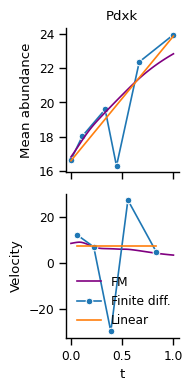

In [338]:
protein = "Pdxk"
model = "IP-Eco"
tissue = "Plasma"

obs = (
    df.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("time", as_index=False)["abundance"]
    .mean()
    .sort_values("time")
)

vel = (
    runs.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("t", as_index=False)["velocity"]
    .mean()
)

fd = linear_model_interval_df.reset_index().query(
    "protein == @protein and model == @model and tissue == @tissue"
)
fm_abundance = (
    runs.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("t", as_index=False)["abundance"]
    .mean()
)

linear_fit = (
    linear_model_df.query(
        "protein == @protein and model == @model and tissue == @tissue"
    )
    .iloc[0]
)

linear_abundance = pd.DataFrame(
    {
        "t": np.linspace(0, 1, 101),
    }
)
linear_abundance["abundance"] = (
    linear_fit["linear_intercept"]
    + linear_fit["linear_velocity"] * linear_abundance["t"]
)

fig, axs = plt.subplots(2, 1, figsize=(2,4), sharex=True)

sns.lineplot(obs, x="time", y="abundance", marker="o", ax=axs[0], label="Observed")
sns.lineplot(
    fm_abundance,
    x="t",
    y="abundance",
    ax=axs[0],
    label="FM",
    color="purple",
)
sns.lineplot(
    linear_abundance,
    x="t",
    y="abundance",
    ax=axs[0],
    label="Linear",
    color="tab:orange",
)
axs[0].set_ylabel("Mean abundance")
axs[0].legend().remove()
sns.lineplot(vel, x="t", y="velocity", ax=axs[1], label="FM", color="purple")
sns.lineplot(fd, x="mean_time", y="finite_difference", marker="o", label="Finite diff.")
sns.lineplot(fd, x="mean_time", y="linear_velocity",  label="Linear")
axs[0].set_title(protein)
axs[1].set_xlabel("t")
axs[1].set_ylabel("Velocity")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
#plt.savefig(f"/Users/erikhartman/dev/flow-matching/panels/sepsis/{protein}.svg", bbox_inches="tight")

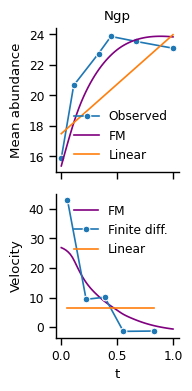

In [319]:
protein = "Ngp"
model = "IP-Eco"
tissue = "Plasma"

obs = (
    df.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("time", as_index=False)["abundance"]
    .mean()
    .sort_values("time")
)

vel = (
    runs.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("t", as_index=False)["velocity"]
    .mean()
)

fd = linear_model_interval_df.reset_index().query(
    "protein == @protein and model == @model and tissue == @tissue"
)
fm_abundance = (
    runs.query("protein == @protein and model == @model and tissue == @tissue")
    .groupby("t", as_index=False)["abundance"]
    .mean()
)

linear_fit = (
    linear_model_df.query(
        "protein == @protein and model == @model and tissue == @tissue"
    )
    .iloc[0]
)

linear_abundance = pd.DataFrame(
    {
        "t": np.linspace(0, 1, 101),
    }
)
linear_abundance["abundance"] = (
    linear_fit["linear_intercept"]
    + linear_fit["linear_velocity"] * linear_abundance["t"]
)

fig, axs = plt.subplots(2, 1, figsize=(2,4), sharex=True)

sns.lineplot(obs, x="time", y="abundance", marker="o", ax=axs[0], label="Observed")
sns.lineplot(
    fm_abundance,
    x="t",
    y="abundance",
    ax=axs[0],
    label="FM",
    color="purple",
)
sns.lineplot(
    linear_abundance,
    x="t",
    y="abundance",
    ax=axs[0],
    label="Linear",
    color="tab:orange",
)
axs[0].set_ylabel("Mean abundance")
axs[0].legend(frameon=False)
sns.lineplot(vel, x="t", y="velocity", ax=axs[1], label="FM", color="purple")
sns.lineplot(fd, x="mean_time", y="finite_difference", marker="o", label="Finite diff.")
sns.lineplot(fd, x="mean_time", y="linear_velocity",  label="Linear")
axs[0].set_title(protein)
axs[1].set_xlabel("t")
axs[1].set_ylabel("Velocity")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(f"/Users/erikhartman/dev/flow-matching/panels/sepsis/{protein}.svg", bbox_inches="tight")

In [320]:
# get smoothness of velocity by computing difference of finite difference and compare with derivative of velocity
def interval_roughness(group, value_col):
    group = group.sort_values("interval_mid")
    values = group[value_col].to_numpy()
    mids = group["interval_mid"].to_numpy()

    dt = np.diff(mids)
    dv = np.diff(values)

    return np.sum(np.abs(dv / dt))


interval_velocity_grouped = interval_velocity_grouped.reset_index()

interval_velocity_grouped["interval_mid"] = (
    interval_velocity_grouped["time"] + interval_velocity_grouped["time_next"]
) / 2

smoothness = (
    interval_velocity_grouped
    .groupby(["protein", "tissue", "model"])
    .apply(
        lambda g: pd.Series(
            {
                "finite_difference_roughness": interval_roughness(
                    g, "finite_difference"
                ),
                "velocity_roughness": interval_roughness(
                    g, "velocity"
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

interval_velocity_grouped = interval_velocity_grouped.merge(
    smoothness,
    on=["protein", "tissue", "model"],
    how="left",
)

interval_velocity_grouped["roughness_ratio"] = (
    interval_velocity_grouped["finite_difference_roughness"]
    / interval_velocity_grouped["velocity_roughness"]
)

In [321]:
interval_velocity_grouped.sort_values("velocity", ascending=False)

,protein,tissue,model,time,time_next,velocity,finite_difference,mean_time,interval_mid,finite_difference_roughness,velocity_roughness,roughness_ratio
14724,Saa2,Plasma,IP-Eco,0.0,0.111111,29.866063,43.621933,0.055556,0.055556,240.353829,139.919176,1.717805
9967,Lcn2,Plasma,IP-Eco,0.0,0.111111,27.687920,49.134451,0.055556,0.055556,329.445013,138.253647,2.382903
10838,Ngp,Plasma,IP-Eco,0.0,0.111111,25.539698,42.990943,0.055556,0.055556,275.560507,140.447096,1.962024
14657,Saa1,Plasma,IP-Eco,0.0,0.111111,25.109535,29.764846,0.055556,0.055556,166.980042,117.349153,1.422934
3468,Chil3,Plasma,IP-Eco,0.0,0.111111,22.285957,42.232115,0.055556,0.055556,327.917569,120.363512,2.724393
...,...,...,...,...,...,...,...,...,...,...,...,...
1799,Ass1,Plasma,SC-Spy,0.0,0.166667,-7.350758,-23.619014,0.083333,0.083333,185.321096,88.978794,2.082756
7753,Hsp90ab1,Plasma,IN-Kpn,0.0,0.150000,-7.588879,-15.923664,0.075000,0.075000,79.702539,37.757399,2.110912
115,Aco1,Plasma,IN-Kpn,0.0,0.150000,-7.839646,-24.563256,0.075000,0.075000,145.276990,43.394114,3.347850
4747,Eef1a1,Plasma,SC-Spy,0.0,0.166667,-7.894341,-25.520801,0.083333,0.083333,247.201736,60.062466,4.115744


0.32834307901650794

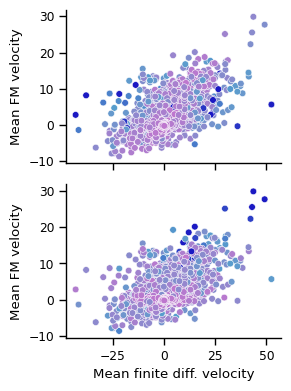

In [330]:
fig, axs = plt.subplots(2,1, figsize=(3,4), sharex=True)
sns.scatterplot(interval_velocity_grouped, x="finite_difference", y="velocity", palette=pink_cmap,
                hue="finite_difference_roughness", ax=axs[0], rasterized=True)
sns.scatterplot(interval_velocity_grouped, x="finite_difference", y="velocity", palette=pink_cmap,
                hue="velocity_roughness", ax=axs[1], rasterized=True)
for ax in axs.ravel():
    ax.legend().remove()
    ax.set_ylabel("Mean FM velocity")

display(r2_score(interval_velocity_grouped["finite_difference"], interval_velocity_grouped["velocity"]))
plt.xlabel("Mean finite diff. velocity")
sns.despine()
plt.tight_layout()
plt.savefig(f"/Users/erikhartman/dev/flow-matching/panels/sepsis/vel_fin_diff.svg", bbox_inches="tight", dpi=300)

-3.07968066644022

0.437298891663913

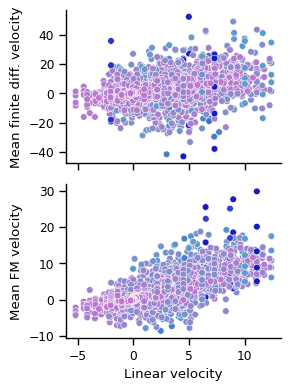

In [332]:
linear_plot_df = interval_velocity_grouped.merge(
    linear_model_df,
    on=["protein", "tissue", "model"],
    how="left",
)

fig, axs = plt.subplots(2,1, figsize=(3,4), sharex=True)
sns.scatterplot(linear_plot_df, x="linear_velocity", y="finite_difference", hue="finite_difference_roughness",
                 palette=pink_cmap, rasterized=True, ax=axs[0])
sns.scatterplot(linear_plot_df, x="linear_velocity", y="velocity", hue="velocity_roughness",
                 palette=pink_cmap, rasterized=True, ax=axs[1])

for ax in axs.ravel():
    ax.legend().remove()

axs[0].set_ylabel("Mean finite diff. velocity")
axs[1].set_ylabel("Mean FM velocity")

display(r2_score(linear_plot_df["linear_velocity"], linear_plot_df["finite_difference"]))
display(r2_score(linear_plot_df["linear_velocity"], linear_plot_df["velocity"]))
plt.xlabel("Linear velocity")
sns.despine()
plt.tight_layout()
plt.savefig(f"/Users/erikhartman/dev/flow-matching/panels/sepsis/vel_lin.svg", bbox_inches="tight", dpi=300)